# Aerial Image Preprocessing for multi temporal data for Iceland - 1986

Here we process the 1986 dataset with fiducial markers (all are correctly detected).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import hipp
import pandas as pd
from pathlib import Path

# Needed only for rewriting extrinsics file
import geopandas as gpd
import numpy as np
import geoutils as gu
import pyproj

### Downloading files from FTP

In [4]:
# !mkdir -p /mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1986_07_17_aux/raw_images
# !wget -np -A tif -r https://ftp.lmi.is/.stm/joaquin/myr/1986/ -nd -nc -P /mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1986_07_17_aux/raw_images
# !wget -np -A csv -r https://ftp.lmi.is/.stm/joaquin/myr/1986/ -nd -nc -P /mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1986_07_17_aux/

### Setup subfolders and configuration

In [5]:
project_dir = Path("/mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1986_07_17_aux")

paths: dict[str, Path] = {}
paths["raw_images"] = project_dir / "raw_images"
paths["preproc_images"] = project_dir / "preprocessed_images"
paths["crop_images"] = project_dir / "cropped_images"
paths["fiducial_templates"] = project_dir / "fiducial_templates"
paths["qc"] = project_dir / "qc"
paths["detected_fiducials"] = paths["raw_images"] / "detected_fiducial_markers.csv"
paths["tf_detected_fiducials"] = paths["preproc_images"] / "detected_fiducial_markers.csv"
paths["crop_detected_fiducials"] = paths["crop_images"] / "detected_fiducial_markers.csv"
paths["intrinsics"] = project_dir / "camera_model_intrinsics.csv"
paths["extrinsics"] = project_dir / "camera_model_extrinsics.csv"
paths["footprint"] = project_dir / "images_footprint.geojson"
paths["dir"] = project_dir

project_dir.mkdir(parents=True, exist_ok=True)

MAX_WORKERS = 4
QUICKVIEW_FACTOR = 0.2
OVERWRITE = False

In [6]:
# Output CRS for reprojection of extrinsics
out_crs = pyproj.crs.CRS("EPSG:32627")

In [5]:
hipp.tools.generate_quickviews(paths["raw_images"], QUICKVIEW_FACTOR, max_workers=MAX_WORKERS, overwrite=OVERWRITE)

**Note**: For now, I assume all points are exactly at 106 mm from center, as only distances between points is provided in the calib report. To be improved?

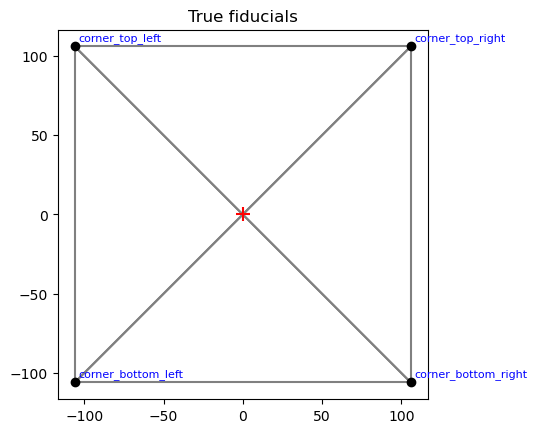

In [6]:
focal_length = 151.76
pixel_pitch = 0.02

fiducial_coords = [
    (106, -106),
    (-106, -106),
    (-106, 106),
    (106, 106),
    (-0.006, 0.010) # ppa
]
intrinsics = hipp.Intrinsics.from_list(focal_length, pixel_pitch, fiducial_coords)
intrinsics.to_csv(paths["intrinsics"])
hipp.aerial.qc.plot_true_fiducials(intrinsics.true_fiducials_mm)

### On first time, click on the interactive plot to identify the marker

Picked the bottom left (most visible) marker.

In [7]:
# first_image_path = sorted(paths["raw_images"].glob("*.tif"))[0]
# corner_marker_coords = hipp.aerial.create_fiducial_templates(first_image_path, paths["fiducial_templates"], corner=True, distance_around_fiducial=60, subpixel_distance_around_fiducial=150)

### For reproducibility, save the markers template location for next runs

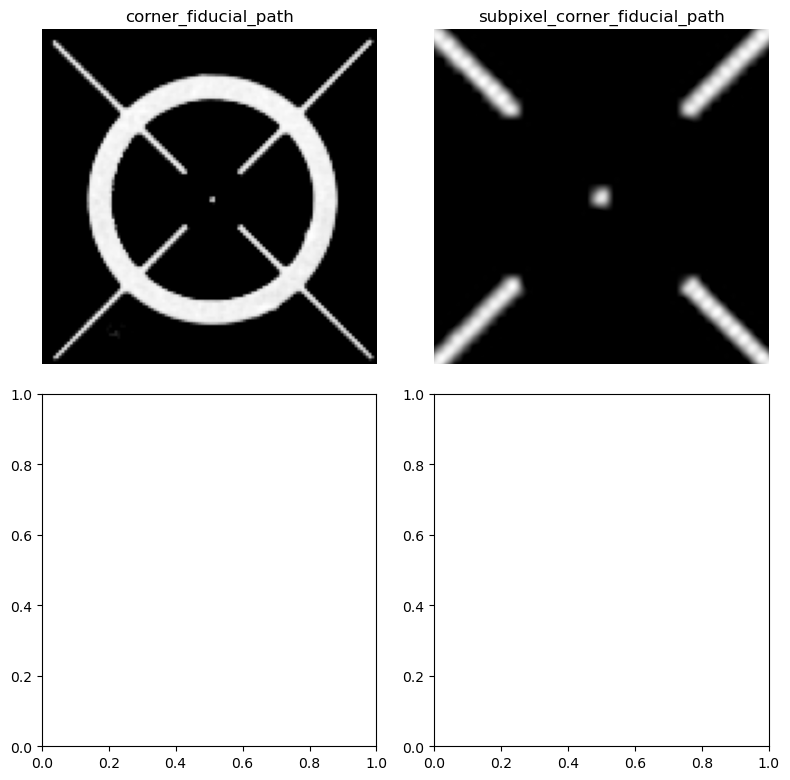

In [8]:
first_image_path = sorted(paths["raw_images"].glob("*.tif"))[0]

saved_coords_corner = {'fiducial_coordinate': (1525, 11310), 'subpixel_center_coordinate': (489, 488)}

_ = hipp.aerial.create_fiducial_templates(first_image_path, paths["fiducial_templates"], corner=True, distance_around_fiducial=60, subpixel_distance_around_fiducial=150, **saved_coords_corner)
hipp.aerial.qc.plot_fiducial_templates(paths["fiducial_templates"])

Fiducial detections:   0%|          | 0/93 [00:00<?, ?Image/s]

Fiducial detections: 100%|██████████| 93/93 [00:12<00:00,  7.50Image/s]


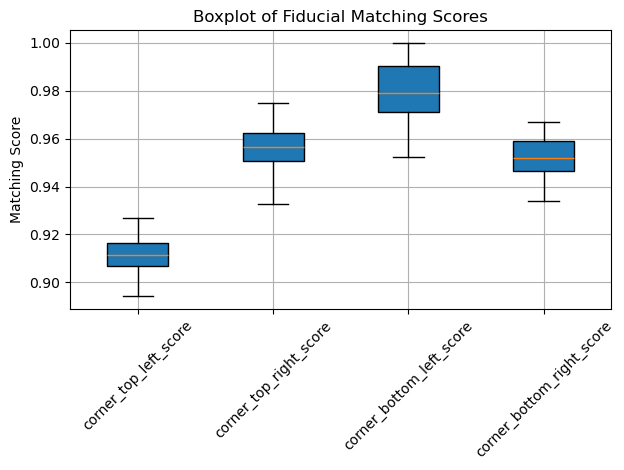

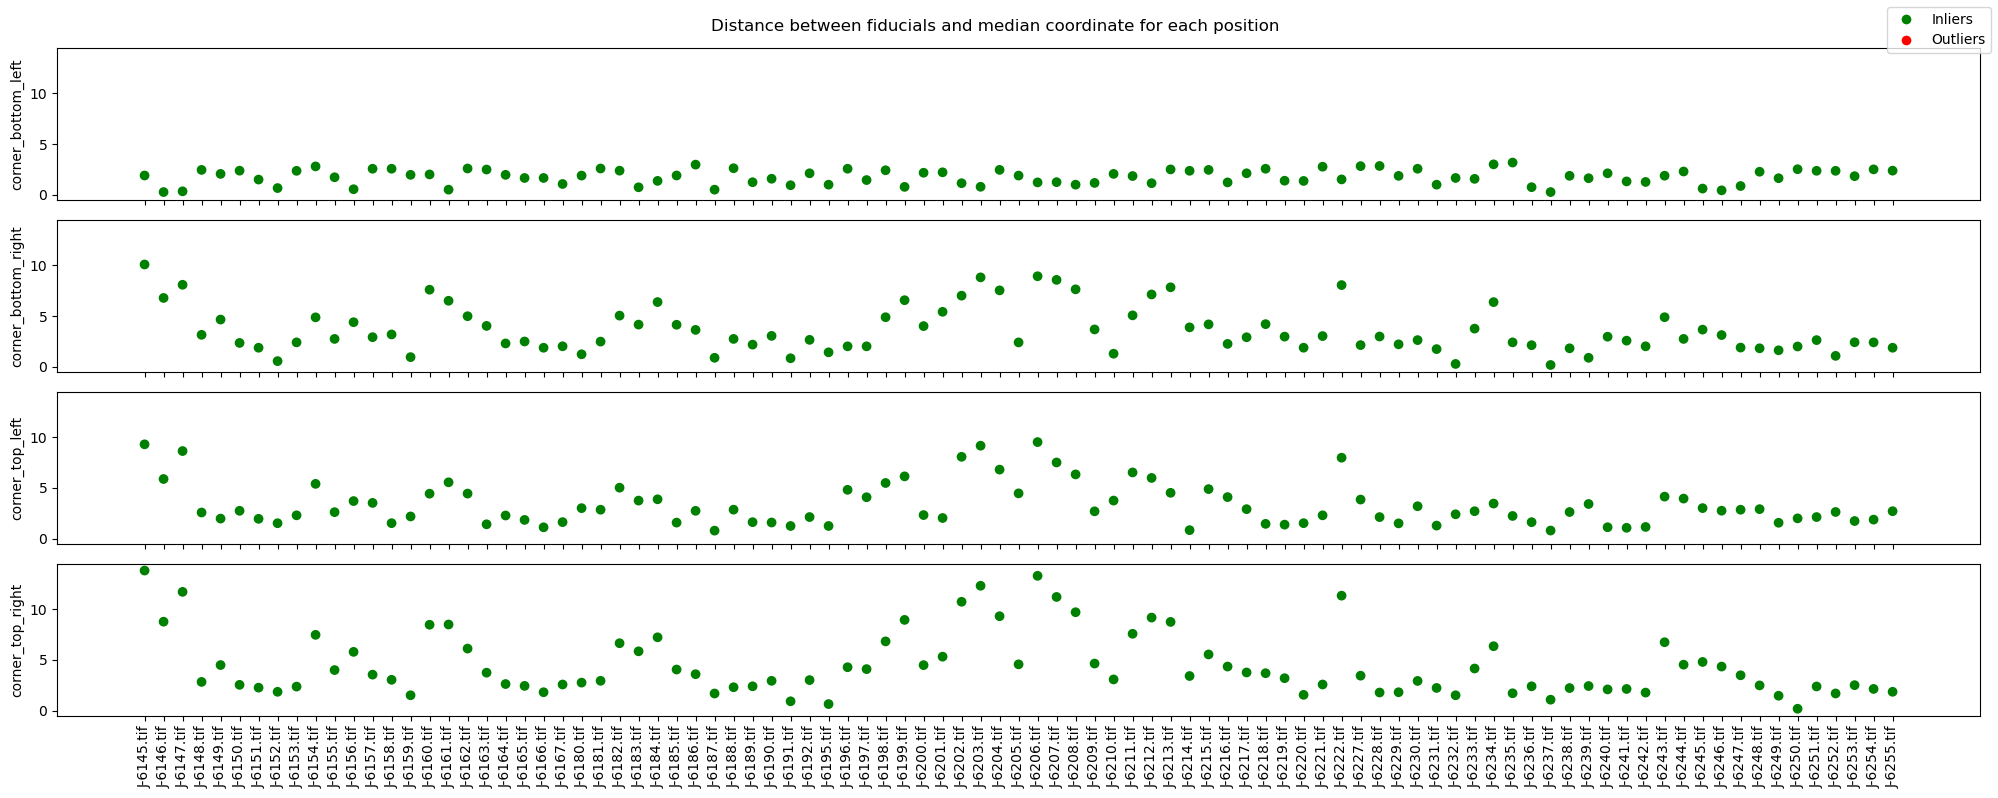

In [9]:
detected_fiducials_df = hipp.aerial.iter_detect_fiducials(paths["raw_images"], paths["fiducial_templates"], grid_size=7, max_workers=MAX_WORKERS)

# filter detection and save them into a csv
filtered_detected_fiducials_df = hipp.aerial.filter_detected_fiducials(detected_fiducials_df)
filtered_detected_fiducials_df.round(2).to_csv(paths["detected_fiducials"])

# plot matching score
output_plot_path = paths["qc"] / "detection_score_boxplot.png"
hipp.aerial.qc.plot_detection_score_boxplot(detected_fiducials_df, show=True, output_plot_path=output_plot_path)

# plot fiducials filtering
output_plot_path = paths["qc"] / "fiducials_filtering.png"
hipp.aerial.qc.plot_fiducials_filtering(detected_fiducials_df,filtered_detected_fiducials_df, show=True, output_plot_path=output_plot_path)

# plot individuals detection
output_dir = paths["qc"] / "individual_detections"
hipp.aerial.qc.generate_detection_qc_plots(paths["raw_images"], detected_fiducials_df, output_dir)


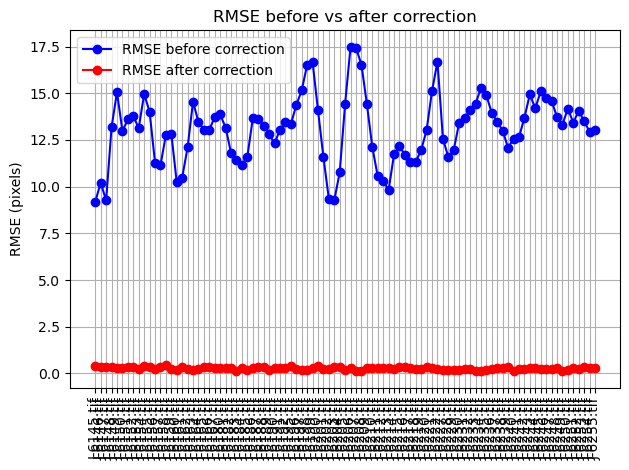

Generating quickviews: 100%|██████████| 93/93 [07:06<00:00,  4.58s/image]


In [10]:
intrinsics = hipp.Intrinsics.from_csv(paths["intrinsics"])
image_square_dim = int(228.6 / intrinsics.pixel_pitch) - 5 

fiducials_df = pd.read_csv(paths["detected_fiducials"], index_col="image_id")

transformations = hipp.aerial.compute_transformations(fiducials_df, intrinsics.true_fiducials_mm, image_square_dim, intrinsics.pixel_pitch)

# save the transformed detected fiducial markers (coordinate of fiducials in preprocessed images)
paths["tf_detected_fiducials"].parent.mkdir(parents=True, exist_ok=True)
hipp.aerial.warp_fiducials_df(fiducials_df, transformations).round(2).to_csv(paths["tf_detected_fiducials"])

# plot the correction to ensure it's correct
hipp.aerial.qc.plot_fiducials_correction(fiducials_df, transformations, intrinsics.true_fiducials_mm, intrinsics.pixel_pitch)

# Image warping
hipp.aerial.iter_image_restitution(
    paths["raw_images"], 
    paths["preproc_images"], 
    transformations,
    image_square_dim=image_square_dim,
    max_workers=MAX_WORKERS,
    overwrite=OVERWRITE
)
hipp.tools.generate_quickviews(paths["preproc_images"], factor=QUICKVIEW_FACTOR, max_workers=MAX_WORKERS, overwrite=OVERWRITE)

### Reproject camera extrinsics to ouput CRS and save

In [8]:
# File provided by Joaquin, contains lat/lon values
gdf = gpd.read_file(project_dir / "cam_centeres_19860717_frm.csv")
coords_latlon = np.array((gdf["lat"].values, gdf["lon"].values))
                         
# Reproject to output CRS
x_map, y_map = gu.projtools.reproject_from_latlon(coords_latlon, out_crs)

# Save to extrinsics CSV file
gdf["x_map"] = x_map
gdf["y_map"] = y_map
gdf.to_csv(paths["extrinsics"], index=False)